# Circuit analysis of frequency dependence. With blue inductance #

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
om = np.linspace(0.5*10**(9),8*10**(9),500000)*(2*np.pi)
freq_GHz = om/(2*np.pi) /10**9

L_0 = 0.2*10**(-9) #H
L_q = 15*10**(-9) #H
C_g2 = 109*10**(-15) #F
C_g1 = 100*10**(-15) #F
C_q = 15*10**(-15)
C_eff =  67*10**(-15) #F
C_0 = 0.12*10**(-15) #F
R = 50 #ohm
V_d = 1 #V

Z_eff2 = 1/(1j*om*C_g2) +1/(1j*om*C_q + (1/(1j*om*L_q)))
Z_eff1 = 1/(1j*om*C_0) + 1/(1j*om*C_g1 + (1/Z_eff2))

I_1 = V_d/(R+ 1/(1/(1j*om*L_0) +1/(Z_eff1)))
Z_node1 = 1/(1/(1j*om*L_0) +1/(Z_eff1)) 
V_node1 = I_1*Z_node1

I_3 = V_node1/Z_eff1
I_q = I_3*((1/(1j*om*C_g1))/((1/(1j*om*C_g1) +Z_eff2)))
Z_q = 1/(1j*om*C_q + 1/(1j*om*L_q))


V_q_ind = I_q*Z_q

V_q_2_ind = V_d*(1/(R+R*(Z_eff1/(1j*om*L_0))+Z_eff1))*(1/(1+Z_eff2*1j*om*C_g1))*(1/(1j*om*C_q + 1/(1j*om*L_q)))

#both give the same solution as they should
V_q_ind = np.absolute(V_q_ind) 
V_q_2_ind = np.absolute(V_q_2_ind)

#calculate db scale:
V_q_dB_ind = 20*np.log10(V_q_ind)

Text(0, 0.5, 'Voltage differential (V)')

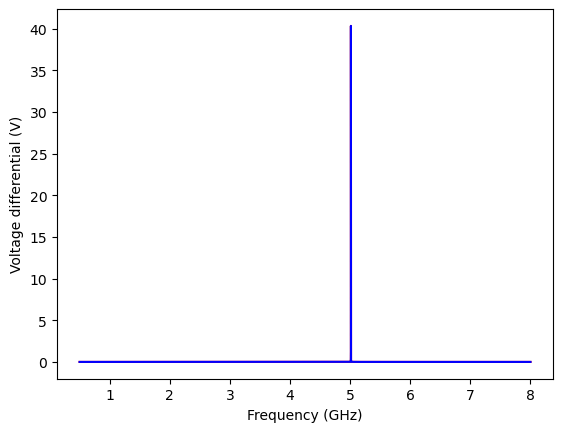

In [38]:
plt.plot(freq_GHz,V_q_ind,'r',label='Volts')
plt.plot(freq_GHz,V_q_2_ind,'b',label='Volts')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Voltage differential (V)')

Text(0, 0.5, 'Voltage differential (V)')

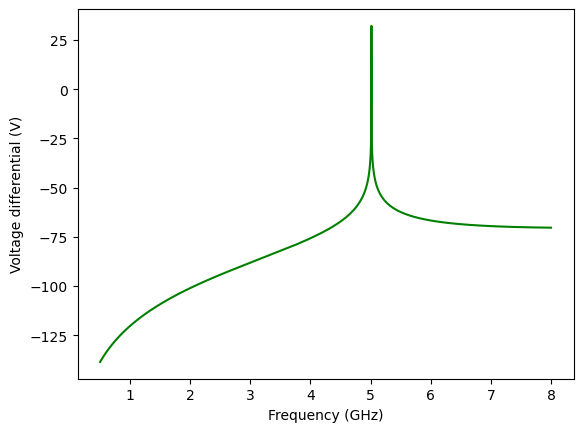

In [39]:
plt.plot(freq_GHz,V_q_dB_ind,'g',label='dB')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Voltage differential (V)')

# Frequency dependence without blue inductance #

In [26]:
Z_eff = 1/(1j*om*C_g2) +1/(1j*om*C_q + (1/(1j*om*L_q)))

Z_node1 = 1/((1j*om*C_g1) +1/(Z_eff)) 

I_1 = V_d/(R+ 1/(1j*om*C_0) +Z_node1)
V_node1 = I_1*Z_node1

I_q = V_node1/Z_eff

Z_q = 1/(1j*om*C_q + 1/(1j*om*L_q))
V_q = I_q*Z_q

V_q_2 = V_d*(Z_node1/(R+1/(1j*om*C_0)+Z_node1))*(Z_q/Z_eff)

#give the same
V_q = np.absolute(V_q) 
V_q_2 = np.absolute(V_q_2)
#calculate db scale:
V_q_dB = 20*np.log10(V_q)
V_q_dB_2 = 20*np.log10(V_q_2)

Text(0, 0.5, 'Voltage differential (V)')

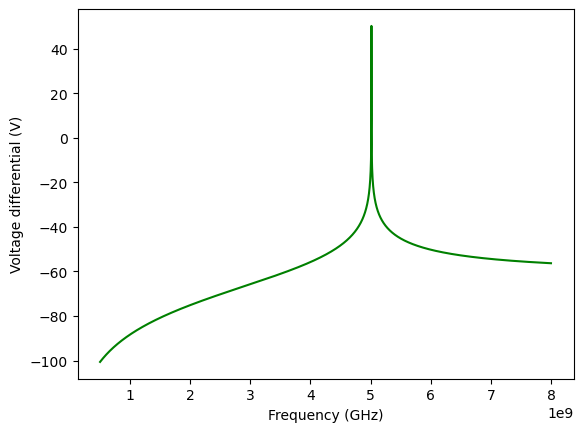

In [27]:
plt.plot(freq,V_q_dB,'g',label='dB')
#plt.plot(freq,V_q_dB_2,'r',label='dB')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Voltage differential (V)')

# Combined

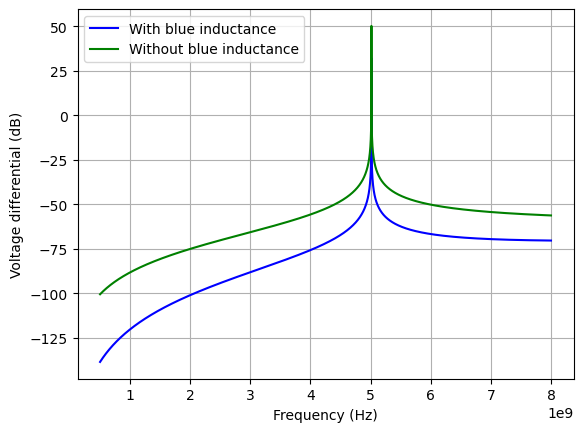

In [29]:
plt.plot(freq,V_q_dB_ind, 'b', label='With blue inductance')
plt.plot(freq,V_q_dB,'g',label='Without blue inductance')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Voltage differential (dB)')
plt.legend()
plt.grid(True)
#plt.savefig('python_circuit_analysis.pdf')
plt.show()

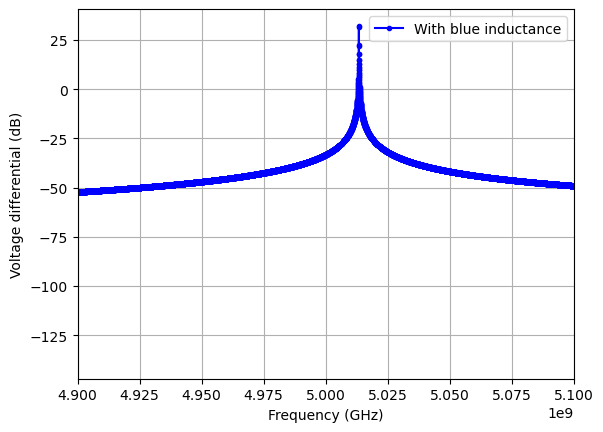

In [19]:
plt.plot(freq,V_q_dB_ind, '.-b', label='With blue inductance')
plt.xlim(4.9e9,5.1e9)
#plt.ylim(25,50)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Voltage differential (dB)')
plt.legend()
plt.grid(True)

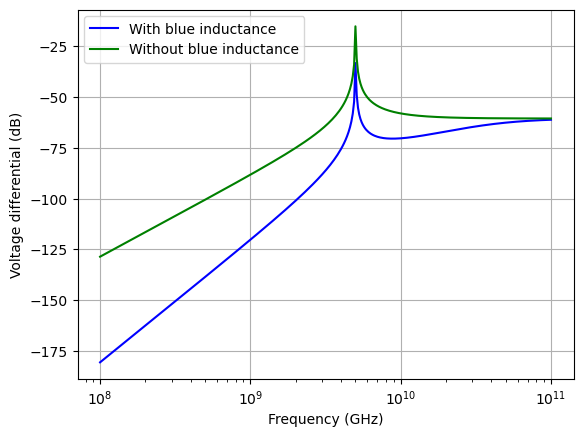

In [41]:
om = np.linspace(0.1*10**(9),100*10**(9),1000)*(2*np.pi)
freq2_GHz = om/(2*np.pi) /10**9

#With
Z_eff2 = 1/(1j*om*C_g2) +1/(1j*om*C_q + (1/(1j*om*L_q)))
Z_eff1 = 1/(1j*om*C_0) + 1/(1j*om*C_g1 + (1/Z_eff2))

I_1 = V_d/(R+ 1/(1/(1j*om*L_0) +1/(Z_eff1)))
Z_node1 = 1/(1/(1j*om*L_0) +1/(Z_eff1)) 
V_node1 = I_1*Z_node1

I_3 = V_node1/Z_eff1
I_q = I_3*((1/(1j*om*C_g1))/((1/(1j*om*C_g1) +Z_eff2)))
Z_q = 1/(1j*om*C_q + 1/(1j*om*L_q))


V_q_ind = I_q*Z_q

V_q_2_ind = V_d*(1/(R+R*(Z_eff1/(1j*om*L_0))+Z_eff1))*(1/(1+Z_eff2*1j*om*C_g1))*(1/(1j*om*C_q + 1/(1j*om*L_q)))

#both give the same solution as they should
V_q_ind = np.absolute(V_q_ind) 
V_q_2_ind = np.absolute(V_q_2_ind)

#calculate db scale:
V_q_dB_ind = 20*np.log10(V_q_ind)
#without
Z_eff = 1/(1j*om*C_g2) +1/(1j*om*C_q + (1/(1j*om*L_q)))

Z_node1 = 1/((1j*om*C_g1) +1/(Z_eff)) 

I_1 = V_d/(R+ 1/(1j*om*C_0) +Z_node1)
V_node1 = I_1*Z_node1

I_q = V_node1/Z_eff

Z_q = 1/(1j*om*C_q + 1/(1j*om*L_q))
V_q = I_q*Z_q

V_q = np.absolute(V_q) 

#calculate db scale:
V_q_dB = 20*np.log10(V_q)


plt.plot(freq2,V_q_dB_ind, 'b', label='With blue inductance')
plt.plot(freq2,V_q_dB,'g',label='Without blue inductance')
plt.xscale('log')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Voltage differential (dB)')
plt.legend()
plt.grid(True)
#plt.savefig('python_circuit_analysis_loglog.pdf')
plt.show()